In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler   

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.style.use("ggplot")

import matplotlib
matplotlib.rcParams["figure.figsize"] = (10,6)

from IPython.display import display
import joblib

In [2]:
pd.options.display.max_columns = 100
pd.options.display.max_colwidth = 200
pd.options.display.max_rows = 100

In [3]:
xls_internal_path = "data/cibil_score/Internal_Bank_Dataset.xlsx"
xls_external_path = "data/cibil_score/External_Cibil_Dataset.xlsx"

In [4]:
df_internal = pd.read_excel(xls_internal_path)

In [5]:
df_external = pd.read_excel(xls_external_path)

In [6]:
df_internal.columns

Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
       'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
       'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL'],
      dtype='object')

In [7]:
df_external.columns

Index(['PROSPECTID', 'time_since_recent_payment',
       'time_since_first_deliquency', 'time_since_recent_deliquency',
       'num_times_delinquent', 'max_delinquency_level',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
       'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq',
       'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m',
       'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m',
       'MARITALSTATUS', 'EDUCATION', 'AGE', 'GENDER', 'NETMONTHLYINCOME',
       'Time_With_Curr_Empr', 'pct_of_active_TLs_ever',
       'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_utilization',
       'CC_Flag', 'PL_utilization', 'PL_Fla

In [5]:
# Merge the two dataframes, inner join so that no nulls are present
# df = pd. merge ( df_internal, df_external, how ='inner', left_on = ['PROSPECTID'], right_on = ['PROSPECTID'] )

In [4]:
# df.to_csv("data/cibil_score/cibil_score.csv")

In [ ]:
# df[:100].to_csv("data/cibil_score/practice_data.csv")

In [21]:
df = pd.read_csv("data/cibil_score/cibil_score.csv")
df = df.drop(columns=['Unnamed: 0'])

Check the column names, remove space, put them in lowercase and rename if the columns name is not clear

In [22]:
# convert the columns names into lowercase and trim extra spaces
df.columns = [col.lower().strip() for col in df.columns]

Check Duplicates

In [23]:
print(df.duplicated().sum())

0


Check Numeric Columns

In [6]:
numeric_columns = df.select_dtypes(

    include=np.number

).columns

print(len(numeric_columns))

numeric_columns

81


Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       'total_tl_opened_l12m', 'tot_tl_closed_l12m', 'pct_tl_open_l12m',
       'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl', 'cc_tl',
       'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num_lss_6mts', 'n

Categorical Features

In [7]:
categorical_columns = df.select_dtypes(
    include="object"
).columns
print(len(categorical_columns))
categorical_columns

6


Index(['maritalstatus', 'education', 'gender', 'last_prod_enq2',
       'first_prod_enq2', 'approved_flag'],
      dtype='object')

Analysis of target variables

In [8]:
print(df["approved_flag"].value_counts())
print(df["credit_score"].isna().sum())

approved_flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64
0


Plot Target Variable

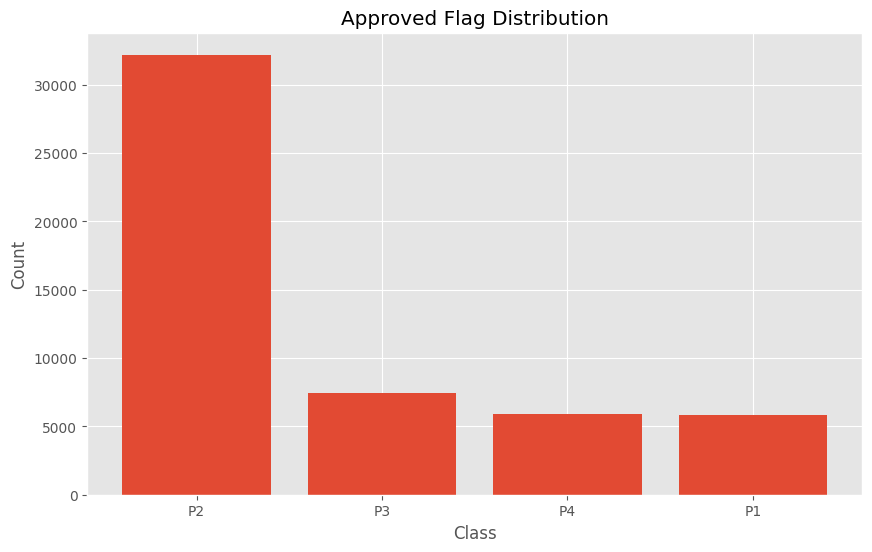

In [9]:
counts = df["approved_flag"].value_counts()

plt.bar(
    counts.index,
    counts.values
)

plt.title("Approved Flag Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

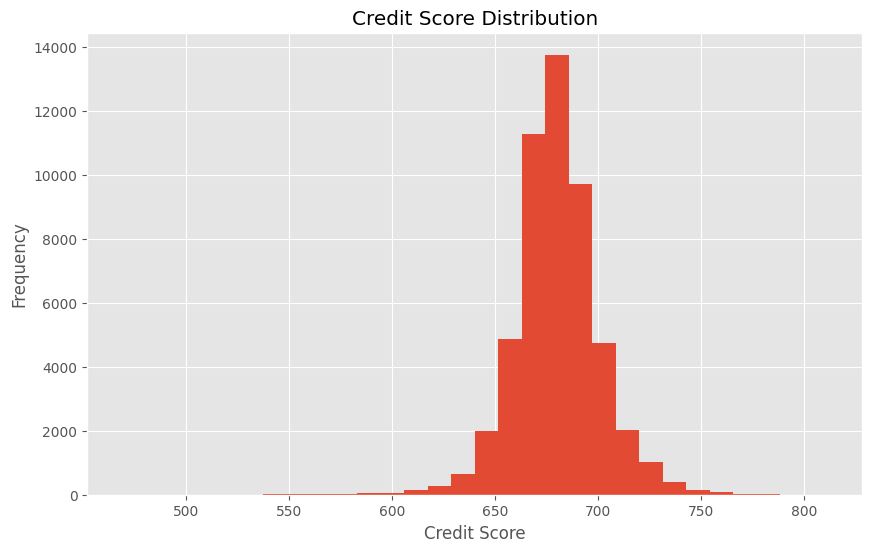

In [10]:
plt.hist(
    df["credit_score"],
    bins=30
)
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.title("Credit Score Distribution")
plt.show()

In [11]:
corr = df.select_dtypes(

    include=np.number

).corr()

In [12]:
corr["credit_score"].sort_values(

ascending=False

)

credit_score                    1.000000
num_std_12mts                   0.470303
num_std                         0.464193
num_std_6mts                    0.441837
age                             0.272582
other_tl                        0.258235
secured_tl                      0.223383
tot_closed_tl                   0.206652
total_tl                        0.202859
pct_closed_tl                   0.182756
time_with_curr_empr             0.176875
home_tl                         0.168260
hl_flag                         0.162458
gl_flag                         0.149753
auto_tl                         0.148962
gold_tl                         0.129388
tot_active_tl                   0.099566
tot_tl_closed_l12m              0.083321
pl_tl                           0.078842
tot_missed_pmnt                 0.075532
time_since_recent_payment       0.056669
num_sub                         0.047607
pl_flag                         0.037956
tot_tl_closed_l6m               0.031527
cc_tl           

In [13]:
np.max(df["netmonthlyincome"])

2500000

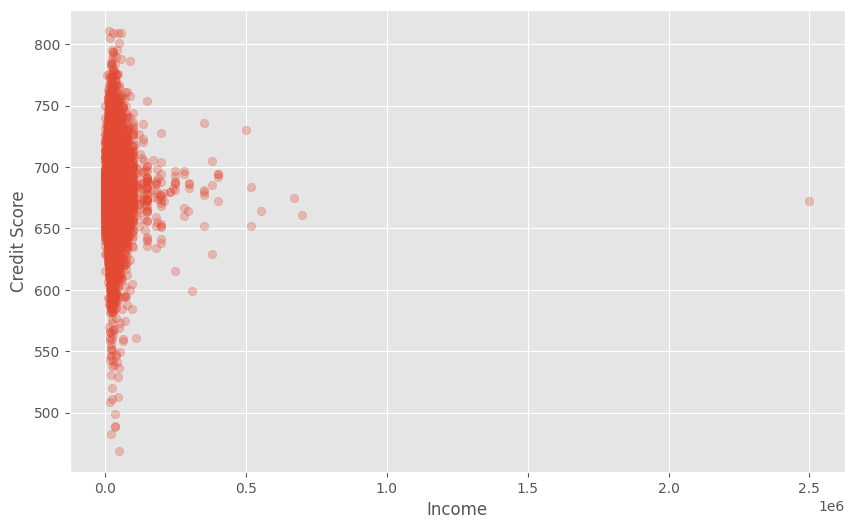

In [14]:
# the alpha parameter controls the transparency of the plot markers,
# accepting values between 0 (fully transparent) and 1 (fully opaque)
plt.scatter(
    df["netmonthlyincome"],
    df["credit_score"],
    alpha=0.3
)

plt.xlabel("Income")
plt.ylabel("Credit Score")
plt.show()

(array([2.3178e+04, 0.0000e+00, 0.0000e+00, 2.8137e+04, 1.4000e+01,
        3.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-99999. , -72619.1, -45239.2, -17859.3,   9520.6,  36900.5,
         64280.4,  91660.3, 119040.2, 146420.1, 173800. ]),
 <BarContainer object of 10 artists>)

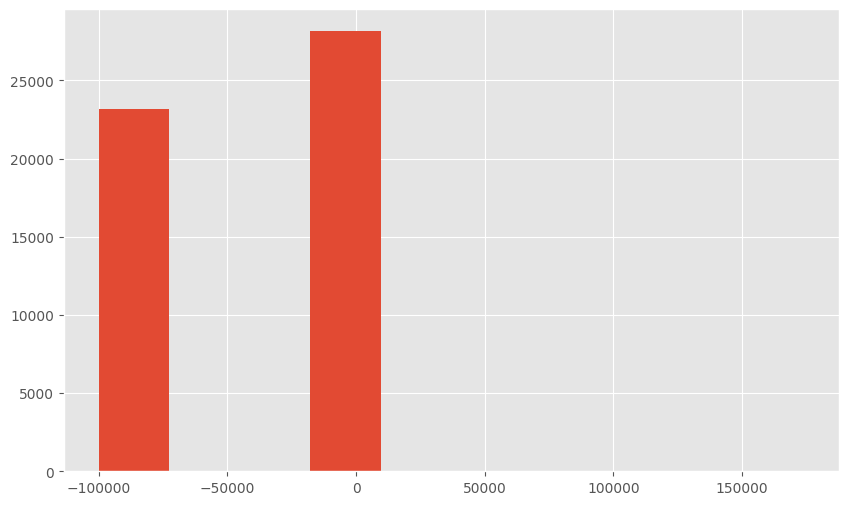

In [15]:
plt.hist(df["max_unsec_exposure_inpct"])

(array([5.1301e+04, 2.8000e+01, 6.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([      0.,  250000.,  500000.,  750000., 1000000., 1250000.,
        1500000., 1750000., 2000000., 2250000., 2500000.]),
 <BarContainer object of 10 artists>)

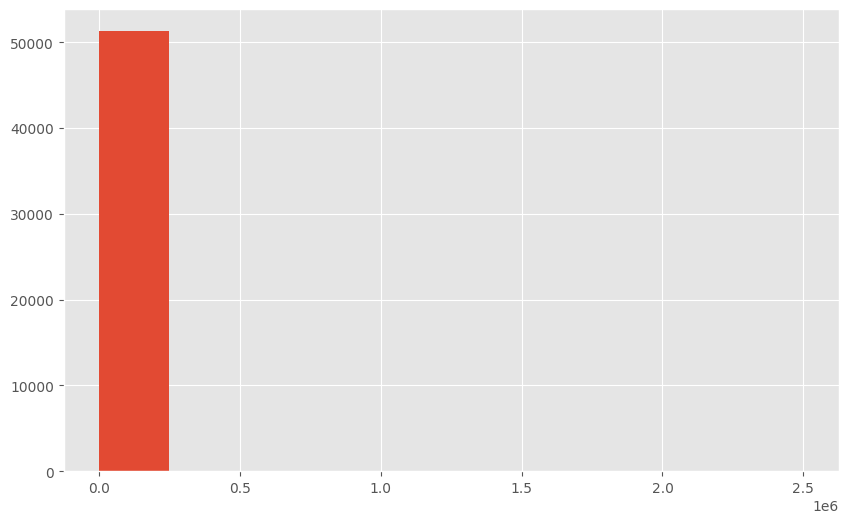

In [16]:
plt.hist(df['netmonthlyincome'])

In [17]:
df["netmonthlyincome_log"] = np.log1p(df["netmonthlyincome"])

(array([5.8000e+01, 1.0800e+02, 1.7000e+01, 0.0000e+00, 1.5000e+01,
        1.6800e+02, 3.8577e+04, 1.2275e+04, 1.1500e+02, 3.0000e+00]),
 array([ 0.        ,  1.47318017,  2.94636034,  4.41954051,  5.89272068,
         7.36590084,  8.83908101, 10.31226118, 11.78544135, 13.25862152,
        14.73180169]),
 <BarContainer object of 10 artists>)

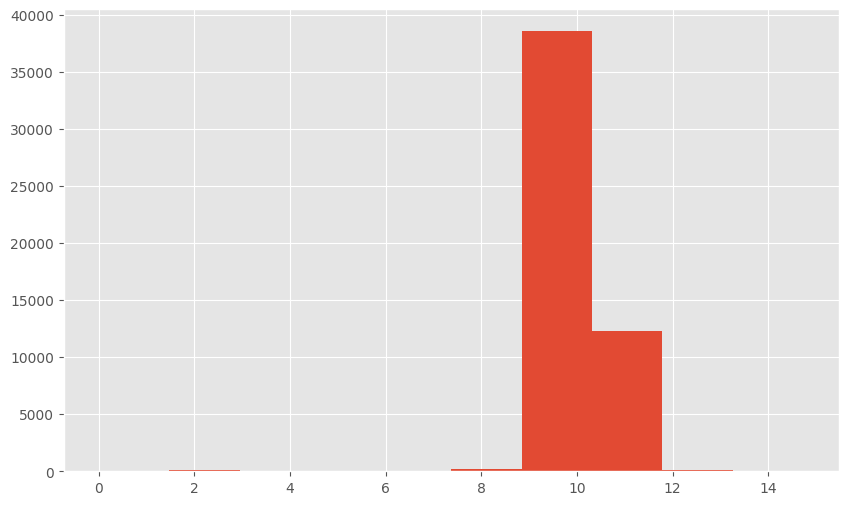

In [19]:
plt.hist(df['netmonthlyincome_log'])

In [20]:
df = df.drop(columns=['netmonthlyincome'])

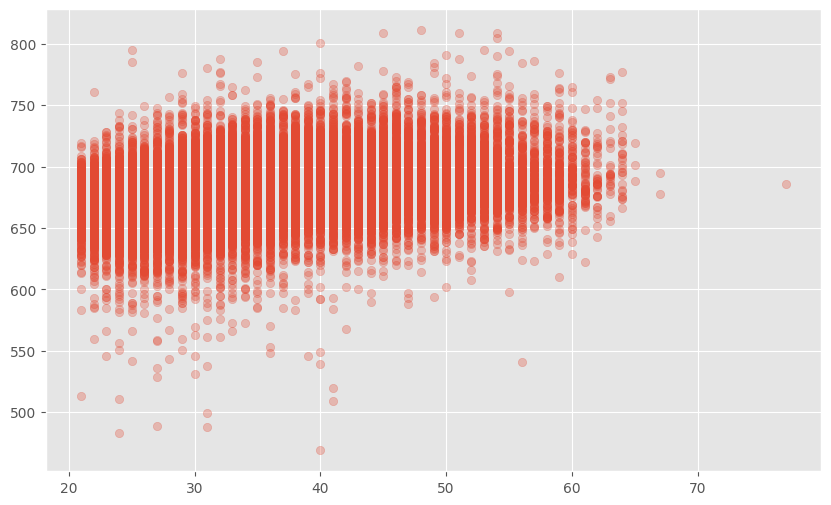

In [17]:
plt.scatter(
    df["age"],
    df["credit_score"],
    alpha=0.3
)

plt.show()

In [18]:
missing_count = (df == -99999).sum()

missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({

    "Missing Count":missing_count,

    "Missing Percentage":missing_percent

})

missing_df = missing_df[missing_df["Missing Count"]>0]

missing_df = missing_df.sort_values(

    by="Missing Percentage",

    ascending=False

)

missing_df

,Missing Count,Missing Percentage
cc_utilization,47636,92.792582
pl_utilization,44435,86.557192
time_since_first_deliquency,35949,70.026882
time_since_recent_deliquency,35949,70.026882
max_delinquency_level,35949,70.026882
max_unsec_exposure_inpct,23178,45.149603
max_deliq_6mts,12890,25.109085
max_deliq_12mts,10832,21.100203
pl_enq_l12m,6321,12.312997
enq_l3m,6321,12.312997


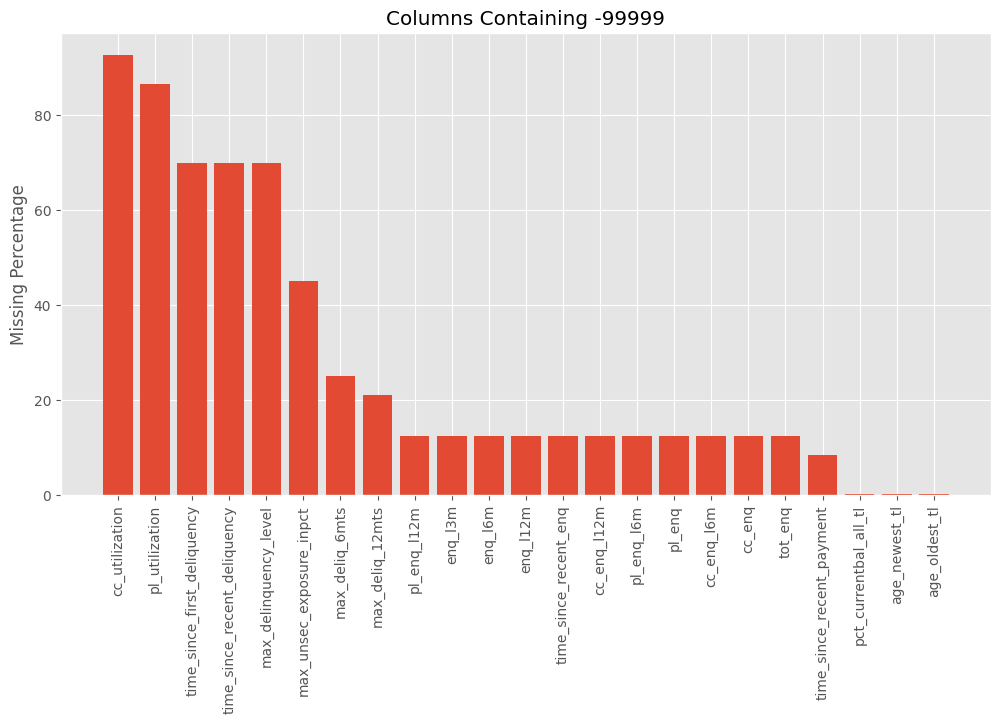

In [19]:
plt.figure(figsize=(12,6))

plt.bar(

    missing_df.index,

    missing_df["Missing Percentage"]

)

plt.xticks(rotation=90)

plt.ylabel("Missing Percentage")

plt.title("Columns Containing -99999")

plt.show()

In [20]:
# df = df_copy.copy()

In [21]:
df_copy = df.copy()

Filling Missing Values
1. Columns having more than 80%, drop

In [22]:
high_missing = [
    "cc_utilization",
    "pl_utilization"
]
df.drop(
    columns=high_missing,
    inplace=True
)

In [23]:
median_columns = [
    "age_oldest_tl",
    "age_newest_tl",
    "pct_currentbal_all_tl",
    "time_since_recent_payment"
]
for col in median_columns:
    df[col] = df[col].replace(
        -99999,
        np.nan
    )

In [24]:
for col in median_columns:
    median = df[col].median()
    df[col].fillna(
        median,
        inplace=True
    )
df[median_columns].isna().sum()

age_oldest_tl                0
age_newest_tl                0
pct_currentbal_all_tl        0
time_since_recent_payment    0
dtype: int64

In [25]:
"""
Delinquency:
Features like num_times_30p_dpd or delinq_2yrs count how many 
separate instances a person crossed that late-payment threshold 
over a specific timeframe (such as the past 6 months, 12 months, or 2 years).
"""
delinquency_columns = [
    "max_delinquency_level",
    "max_deliq_6mts",
    "max_deliq_12mts",
    "time_since_recent_deliquency",
    "time_since_first_deliquency"
]

df[delinquency_columns] = df[delinquency_columns].replace(
    -99999,
    0
)

In [26]:
# If there is no entry means no enquiry

enquiry_columns = [
    "tot_enq",
    "cc_enq",
    "pl_enq",
    "cc_enq_l6m",
    "cc_enq_l12m",
    "pl_enq_l6m",
    "pl_enq_l12m",
    "enq_l3m",
    "enq_l6m",
    "enq_l12m"
]

df[enquiry_columns] = df[enquiry_columns].replace(-99999, 0)

In [27]:
col = 'time_since_recent_enq'
mask = df[col] == -99999

# semantically correct: "no enquiry ever" -> treat as longer than the longest observed gap
fill_value = df.loc[~mask, col].max() + 1   # or a round number like 9999

df['no_enquiry_flag'] = mask.astype(int)     # keep the signal as its own feature
df[col] = df[col].replace(-99999, fill_value)

In [28]:
df[df["time_since_recent_enq"] == 4769].shape

(6321, 86)

In [29]:
# Maximum unsecured exposure = 0%
# Customer with no unsecured loan
df["max_unsec_exposure_inpct"] = df["max_unsec_exposure_inpct"].replace(-99999,0)

In [30]:
np.max(df["max_unsec_exposure_inpct"])

173800.0

In [31]:
# Verify -99999 with None
(df==-99999).sum().sum()

0

Handling Outliers

Method 1:
Keep if genuine.

Method 2:
Percentiles

Method 3: Log Transforms

In [ ]:
Q1=df[col].quantile(.25)

Q3=df[col].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df[col]=df[col].clip(lower,upper)

In [32]:
def find_outlier_columns(df, method='iqr', factor=1.5, z_thresh=3, exclude=None):
    """
    Scan numeric columns and report which ones have outliers.

    method: 'iqr'    -> flags values outside [Q1 - factor*IQR, Q3 + factor*IQR]
            'zscore' -> flags values with |z-score| > z_thresh (assumes ~normal data)
    exclude: column names to skip (IDs, targets, binary flags)
    """
    exclude = set(exclude or [])
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

    rows = []
    for col in num_cols:
        s = df[col].dropna()
        if method == 'iqr':
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - factor * iqr, q3 + factor * iqr
        else:  # zscore
            z = (s - s.mean()) / s.std(ddof=0)
            lower, upper = s.mean() - z_thresh * s.std(), s.mean() + z_thresh * s.std()

        mask = (s < lower) | (s > upper)
        n_out = mask.sum()
        if n_out > 0:
            rows.append({
                'column': col, 'n_outliers': n_out,
                'pct_outliers': round(n_out / len(s) * 100, 2),
                'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
                'min_val': s.min(), 'max_val': s.max(),
            })

    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False).reset_index(drop=True)

In [33]:
outliers_df = find_outlier_columns(df=df)

In [42]:
df['pct_pl_enq_l6m_of_l12m'].value_counts()

pct_pl_enq_l6m_of_l12m
0.000    40236
1.000     8126
0.500     1036
0.667      463
0.333      326
0.750      213
0.800      115
0.250       89
0.600       85
0.400       83
0.833       60
0.714       47
0.857       46
0.200       35
0.571       33
0.429       26
0.875       22
0.286       19
0.625       19
0.556       18
0.900       16
0.889       15
0.778       13
0.375       12
0.167       12
0.727       10
0.909        9
0.545        9
0.700        7
0.143        7
0.818        7
0.583        7
0.125        5
0.692        5
0.923        5
0.929        4
0.636        4
0.733        4
0.615        4
0.300        4
0.941        3
0.933        3
0.222        3
0.917        3
0.769        3
0.455        3
0.444        3
0.846        3
0.462        2
0.588        2
0.895        2
0.111        2
0.273        2
0.867        2
0.100        2
0.647        2
0.308        2
0.786        2
0.688        2
0.682        1
0.467        1
0.970        1
0.414        1
0.789        1
0.706        1
0.

In [34]:
outliers_df

,column,n_outliers,pct_outliers,lower_bound,upper_bound,min_val,max_val
0,num_std_6mts,11316,22.04,-1.50,2.50,0.0,60.0
1,pct_pl_enq_l6m_of_ever,11100,21.62,0.00,0.00,0.0,1.0
2,pct_pl_enq_l6m_of_l12m,11100,21.62,0.00,0.00,0.0,1.0
3,pl_enq_l6m,11100,21.62,0.00,0.00,0.0,44.0
4,pct_tl_closed_l6m,10473,20.40,-0.08,0.13,0.0,1.0
5,recent_level_of_deliq,10321,20.10,-10.50,17.50,0.0,900.0
6,num_std_12mts,9443,18.39,-4.50,7.50,0.0,122.0
7,time_since_recent_deliquency,9164,17.85,-4.50,7.50,0.0,35.0
8,time_since_recent_payment,8972,17.48,-106.50,321.50,2.0,6065.0
9,pl_tl,8618,16.79,0.00,0.00,0.0,29.0


In [ ]:
# num_std_6mts, num_std_12mts, num_dbt_12mts, num_lss_12mts, num_dbt_6mts, num_lss_6mts, pct_pl_enq_l6m_of_l12m, pct_pl_enq_l6m_of_l12m, pl_enq_l6m

Tree-Based Models: Use algorithms like XGBoost, LightGBM, or Random Forests, which handle skewed count distributions naturally without preprocessing

Binning/Bucketing: Group counts into logical risk tiers (e.g., 0, 1, 2, 3+ missed payments) to smooth out extreme values.

Log Transformation: Apply \(\log(x + 1)\) if you must use a linear regression or neural network model that requires normally distributed inputs

In [ ]:
plt.hist(df['netmonthlyincome'])

KeyboardInterrupt: 

In [51]:
X = pd.get_dummies(
df,
columns=categorical_columns
)

In [33]:
categorical_columns

Index(['maritalstatus', 'education', 'gender', 'last_prod_enq2',
       'first_prod_enq2', 'approved_flag'],
      dtype='object')

In [54]:
X.filter(regex='approved_flag')
# df['maritalstatus_Single'].value_counts()

,approved_flag_P1,approved_flag_P2,approved_flag_P3,approved_flag_P4
0,False,True,False,False
1,False,True,False,False
2,False,True,False,False
3,False,True,False,False
4,True,False,False,False
...,...,...,...,...
51331,False,False,False,True
51332,True,False,False,False
51333,False,False,True,False
51334,False,True,False,False


In [ ]:
encoder = LabelEncoder()
multi_df = df.copy()
multi_df["approved_flag"] = \
encoder.fit_transform(
multi_df["approved_flag"]
)

In [ ]:
X_multi = df.drop(
    columns=[
        "credit_score",
        "approved_flag"
    ]
)
y_multi_lin = df["credit_score"]
y_multi_log = df["approved_flag"]

In [48]:
df["approved_binary_flag"] = \
df["approved_flag"].map({
"P1":1,
"P2":1,
"P3":0,
"P4":0
})

X_binary = df.drop(
    columns=[
        "credit_score",
        "approved_flag",
        "approved_binary_flag"
    ]

)
y_binary = df["approved_binary_flag"]

In [ ]:
scaler = StandardScaler()

X[numeric_columns] = \

scaler.fit_transform(

X[numeric_columns]

)

In [ ]:
joblib.dump(scaler, "processed/standard_scaler.pkl")

In [ ]:
# For above three columns decide what kind of encoding should be done and why?

In [ ]:
# Filling the missing values
# Filling the next or previous values in the column - we cannot apply for every column
# 8% or below missing values the we can apply mean or median again based on column.
# Assign a big value - if the algo can handle nulls
# After converting run the command to check missing values and write down how to fill them
# Four different ways to handle missing values

In [ ]:
df.to_csv("./data/cibil_score/cibil_processed_score.csv")

SyntaxError: invalid syntax (3911349663.py, line 1)

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  
df = pd.read_csv('data.csv')  
# --- Basic overview --- 
print(df.shape) 
print(df.dtypes) 
print(df.describe())
# mean, std, min, max, quartiles 
print(df.isnull().sum()) # missing value counts 
print(df.nunique()) # unique values per column  
# --- Target distribution --- 
df['target'].value_counts(normalize=True) # class proportions  
# --- Univariate: histogram --- 
df['income'].hist(bins=50, figsize=(8,4))
plt.title('Income is right-skewed — consider log transform')
plt.show()  
# --- Univariate: boxplot --- 
df.boxplot(column='loan_amount', by='target') 
plt.show()  
# --- Bivariate: correlation heatmap --- 
corr = df.select_dtypes('number').corr() 
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0) 
plt.title('Correlation Heatmap') 
plt.show()  
# --- Top 5 features by correlation with target --- 
corr['target'].abs().sort_values(ascending=False).head(6)

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns  
# --- Distribution: compare three chart types for the same feature --- 
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) 
df['income'].hist(ax=axes[0], bins=40)       
axes[0].set_title('Histogram') 
df['income'].plot.kde(ax=axes[1])         
axes[1].set_title('KDE Plot') 
df.boxplot(column='income', ax=axes[2])
axes[2].set_title('Boxplot') 
plt.tight_layout(); plt.show()  
# --- Pair plot (top features only) --- 
top_features = ['credit_score','income','loan_amount','num_delays','target'] 
sns.pairplot(df[top_features], hue='target', diag_kind='kde', plot_kws={'alpha':0.4}) 
plt.suptitle('Pair Plot — top 4 features coloured by target', y=1.02) 
plt.show()  
# --- Predicted probability distribution --- 
y_prob = model.predict_proba(X_val)[:, 1] 
plt.figure(figsize=(8, 4)) 
plt.hist(y_prob[y_val==0], bins=40, alpha=0.6, label='Actual 0', color='steelblue') 
plt.hist(y_prob[y_val==1], bins=40, alpha=0.6, label='Actual 1', color='coral') 
plt.xlabel('Predicted probability of class 1') 
plt.title('Good model: two distributions should be well-separated') 
plt.legend(); plt.show()

In [ ]:
import numpy as np 
import pandas as pd 
from sklearn.impute import SimpleImputer, KNNImputer 
from sklearn.preprocessing import FunctionTransformer 
from scipy import stats
# --- Missing value audit --- 
missing = df.isnull().sum() 
missing_pct = (missing / len(df) * 100).round(2) 
print(pd.concat([missing, missing_pct], axis=1, keys=['count','%']).query('count > 0'))
# --- Median imputation (fit on train only!) --- 
imputer = SimpleImputer(strategy='median') 
X_train_imp = imputer.fit_transform(X_train)   
# fit AND transform on train 
X_val_imp = imputer.transform(X_val)          
# transform only on val/test  # --- KNN imputation --- 
knn_imp = KNNImputer(n_neighbors=5) 
X_train_knn = knn_imp.fit_transform(X_train) 
X_val_knn = knn_imp.transform(X_val)  
# --- IQR outlier detection --- 
Q1 = df['income'].quantile(0.25) 
Q3 = df['income'].quantile(0.75) 
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR 
print(f"Outliers below {lower:.0f}: {(df['income'] < lower).sum()}") 
print(f"Outliers above {upper:.0f}: {(df['income'] > upper).sum()}")  
# --- Winsorisation (cap at 1st and 99th percentile) --- 
p01, p99 = df['income'].quantile([0.01, 0.99]) 
df['income_capped'] = df['income'].clip(lower=p01, upper=p99)  
# --- Log transform (for right-skewed features) --- 
df['income_log'] = np.log1p(df['income'])   
# log1p handles zero values

1. pct_tl_closed_l6m(Percentage of Total Loans closed in the last 6 months)

Why it looks like an outlier: This column represents a percentage, natively bounded between 0 and 100. 

You will see a massive spike at 0 (for people who haven't closed loans recently) and a sharp spike at 100 (for people who had only one or two loans and closed them all recently).

Should you treat for outliers? No. Values of 0 and 100 are mathematically valid and highly meaningful. A value of 100% can indicate a borrower aggressively clearing their debt, which is a strong positive signal for a CIBIL score.

The Missing Value Trap: Check your dataset for placeholder values like -99999. If a borrower has never had any loans, the denominator is zero, resulting in a placeholder.

Correct Action: Do not cap or drop extreme values. Cap strictly at 0 and 100 only if there are data anomalies. Treat -99999 as a separate category or let tree models handle it natively.

2. recent_level_of_deliq(The delinquency status or Days Past Due (DPD) score of the most recent late payment)

Why it looks like an outlier: The vast majority of borrowers pay on time, so this column will be heavily skewed toward 0. A tiny fraction of borrowers will have very high numbers like 90, 180, or 360+ (representing months of missed payments). A standard IQR test will flag these high numbers as outliers.

Should you treat for outliers? Absolutely not. High values in this column are the ultimate "red flags" for credit default. If you cap a DPD of 360 down to a lower value, you are hiding the worst delinquencies from your machine learning model.

The Missing Value Trap: Borrowers who have never been delinquent will have no "recent level." Kaggle CIBIL datasets heavily use placeholder values (like -99999) here to represent "Never Delinquent.

"Correct Action: Never use standard outlier scaling. Leave the high valid DPD values untouched. If you are using a linear model, map the -99999 placeholders to 0 and create a binary indicator column ever_delinquent (0 or 1).Would you like to move on to the 

The column pct_pl_enq_l6m_of_ever represents the percentage (%) of a user's lifetime Personal Loan (PL) enquiries that occurred in the last 6 months.Like the payment count columns, this feature should generally not be treated for outliers, though it has a unique mathematical structure that requires specific attention.

Why It Looks Like an Outlier (But Isn't)Natural 100% Cap: If a user only started applying for Personal Loans recently, 100% of their lifetime enquiries happened in the last 6 months. This creates a massive spike of data points at exactly 100.0.High-Risk Indicator: A sudden rush of loan applications in a short window signals "credit hunger" or sudden financial distress. These "outlier" 100% values are highly predictive of a dropping CIBIL score.The Hidden Trap: Missing Values (0/0)The biggest issue with this column is not outliers, but the mathematical trap of division by zero:\(\text{pct\_pl\_enq\_l6m\_of\_ever}=\frac{\text{PL\ Enquiries\ in\ Last\ 6\ Months}}{\text{Total\ Lifetime\ PL\ Enquiries}}\times 100\)If a borrower has never applied for a Personal Loan in their life, the formula tries to divide 0 by 0. In Kaggle CIBIL datasets, this is usually filled with a placeholder value like -99999 or left as NaN.How to Safely Preprocess This Column1. Separate the Placeholders FirstDo not run Z-score or IQR methods on the raw column. A value like -99999 will completely distort your calculations.2. Handle the "Never Enquired" GroupFor Tree Models (XGBoost/LightGBM): Leave -99999 as it is. Tree models easily isolate this specific value into its own branch.For Linear Models/Neural Networks: Replace -99999 or NaN with 0, and create a separate binary indicator column: has_ever_enquired_pl (0 or 1).3. Capping (If Strictly Necessary)If your model is highly sensitive to extreme distributions, cap the values strictly between 0 and 100. Any value outside this range is a placeholder error, not a true financial outlier.

1. They Represent Count Data, Not Continuous MetricsThese columns count occurrences over fixed 6-month and 12-month windows.The maximum value is naturally capped by time (e.g., you cannot have more than 6 or 12 monthly payments per account).High numbers simply mean a borrower has multiple active loan accounts or credit cards running simultaneously.2. High Counts for "STD" Indicate High-Value Usersnum_std_6mts & num_std_12mts: Standard (on-time) payments.A high number (e.g., 36 standard payments in 6 months) indicates a user successfully managing 6 different active loan accounts parallelly (6 × 6 = 36).Treating this as an outlier removes your most creditworthy, high-volume customers.3. High Counts for "DBT" and "LSS" Flag High-Risk Usersnum_dbt_6mts & num_dbt_12mts: Doubtful accounts (severely overdue, typically 180+ days).num_lss_6mts & num_lss_12mts: Loss accounts (uncollectible debt, written off).These events are naturally rare in a population, making them look like statistical outliers.However, these "outliers" are your most critical data points for fraud and default detection. Capping them makes bad borrowers look safer than they are.How to Handle These Columns InsteadInstead of outlier standardisation (like IQR or Z-score capping), use these techniques:Tree-Based Models: Use algorithms like XGBoost, LightGBM, or Random Forests, which handle skewed count distributions naturally without preprocessing.Binning/Bucketing: Group counts into logical risk tiers (e.g., 0, 1, 2, 3+ missed payments) to smooth out extreme values.Log Transformation: Apply \(\log(x + 1)\) if you must use a linear regression or neural network model that requires normally distributed inputs.

2. time_since_recent_payment(Months elapsed since the borrower's last loan or credit card payment)Why it looks like an outlier: Most active borrowers make payments every single month, so this column will have a massive spike at 0 or 1. Borrowers who closed their last loan long ago or have completely inactive accounts will show much higher numbers (e.g., 24 or 36 months). These look like statistical outliers but are completely valid.Should you treat for outliers? No. A high number here indicates an inactive credit user. While not necessarily a bad borrower, a person who hasn't made a credit payment in 3 years is a higher risk to a lender than someone actively paying a bill today.The Missing Value Trap: New-to-credit borrowers who have just opened their first account and haven't hit their first payment cycle yet will trigger a placeholder value (like -99999).Correct Action: Keep the valid high months as they are to preserve the "credit inactivity" signal. Isolate any -99999 placeholders so they do not skew your distributions.

time_since_recent_deliquency(Months elapsed since the borrower's last missed payment)Why it looks like an outlier: For borrowers who rarely miss payments, this number could be very high (e.g., 60 or 120 months ago). More importantly, the vast majority of borrowers have never been delinquent. In Kaggle CIBIL datasets, these non-delinquent individuals are assigned a massive placeholder value like -99999. A standard outlier detection algorithm will flag these placeholders instantly.Should you treat for outliers? No. Valid high numbers (e.g., 48 months) are highly predictive. A delinquency that happened 4 years ago hurts a CIBIL score far less than one that happened 2 months ago. Capping or trimming these numbers destroys this critical time-decay risk signal.Correct Action:Do not use IQR or Z-score capping.Separate the -99999 placeholders immediately.For tree-based models (XGBoost/LightGBM), leave the -99999 untouched; the model learns that this means "perfect borrower."For linear/neural models, replace -99999 with a maximum boundary value (like 999 or the maximum valid month in the dataset) and create a binary column: has_ever_delinquenced (0 or 1).

max_recent_level_of_deliq(The highest severity of delinquency, typically measured in Days Past Due (DPD), recorded during the borrower's recent history)Why it looks like an outlier: Most borrowers maintain clean accounts, meaning a massive majority of your data will cluster at 0. Only a very small percentage of users will show high values like 90, 180, or 360+ DPD. Statistical tests (like IQR) will flag these critical risk numbers as extreme outliers.Should you treat for outliers? Absolutely not. This column captures the peak severity of a borrower's past financial distress. A borrower who peaked at 30 days past due is a vastly different risk profile than someone who peaked at 360 days past due (uncollectible debt). Capping these values makes a highly toxic borrower look like a minor offender.The Placeholder Alert: Borrowers who have a flawless payment history will have no delinquency level. In Kaggle CIBIL datasets, look out for placeholder values like -99999 representing "Never Delinquent."Correct Action: Isolate the -99999 placeholders before doing any analysis. Keep all valid positive DPD values exactly as they are to preserve the risk gradient.

num_times_delinquent(The total count of times the borrower has missed a payment deadline across their history)Why it looks like an outlier: This is pure count data. Most people will be at 0 or 1. A habitual defaulter might have a value of 15 or 20. Because a count of 20 is rare in the general population, it will be statistically flagged as an outlier.Should you treat for outliers? No. A high frequency of delinquency proves chronic repayment issues. This is a critical behavioral signal for credit scoring models.Correct Action: Do not cap or drop these high counts. If you are using linear models or logistic regression, a Log Transformation (\(\log(x + 1)\)) or Binning (e.g., 0, 1, 2, 3, 4+) is the safest way to handle the heavily skewed distribution without losing the underlying risk information. For tree models (XGBoost/LightGBM), pass the data exactly as it is.

num_times_60p_dpd(The number of times a borrower's payments have been overdue by 60+ Days Past Due)Why it looks like an outlier: This is a rare, severe count metric. The vast majority of the population will have a value of 0. Only a very small fraction of chronic defaulters will have counts like 5, 10, or more. A standard statistical test will flag any number greater than 0 as an outlier.Should you treat for outliers? No. Missing a payment by more than 60 days means the account is dangerously close to becoming a Non-Performing Asset (NPA). A borrower who has done this multiple times is an incredibly high-risk data point. Capping or removing these high counts will blind your machine learning model to chronic defaulters.Correct Action: Leave the valid counts untouched. If you are using a linear model or logistic regression, use Binning (e.g., 0, 1, 2, 3+) to handle the heavy skewness. For tree-based models (XGBoost/LightGBM), pass the raw counts exactly as they are.

netmonthlyincome(The verified monthly net income of the borrower)Why it looks like an outlier: This is a continuous monetary variable. In almost all Kaggle credit datasets, income has a massive right skew. You will have a large cluster of average earners, but a few ultra-high-income individuals (e.g., corporate executives or business owners) earning 10x or 100x the median income.Should you treat for outliers? Yes, but cautiously. Unlike the credit risk flags above, true extreme values here can destabilize your model. Furthermore, Kaggle datasets often contain data entry errors (e.g., someone typing their annual income instead of monthly income, or adding extra zeros by mistake).Correct Action:Do not use standard Z-scores: Extreme wealth breaks normal distribution rules.Use Percentile Capping (Winsorization): Cap the extreme upper end at the 99th percentile. This removes typographical errors (like an accidental extra zero) while keeping your high earners in a realistic bracket.Log Transformation: Apply a log transformation (\(\log(\text{income} + 1)\)). This shrinks the distance between an average earner and a multi-millionaire, turning a highly skewed distribution into a bell curve that linear models and neural networks can easily interpret. Tree models also benefit from reduced variance.